# Electrocardiography Analysis from 1-lead Apple Watch

## Original Data

Starting data transformation by reading '/Users/mikkohapponen/Documents/Tiedostot/Koti/Terveys/electrocardiograms/ecg_2024-11-01_1.csv'...
Skipping the first 12 lines of the input file.
Transformation complete. 15360 data points processed.
Displaying plot. Close the plot window to continue.


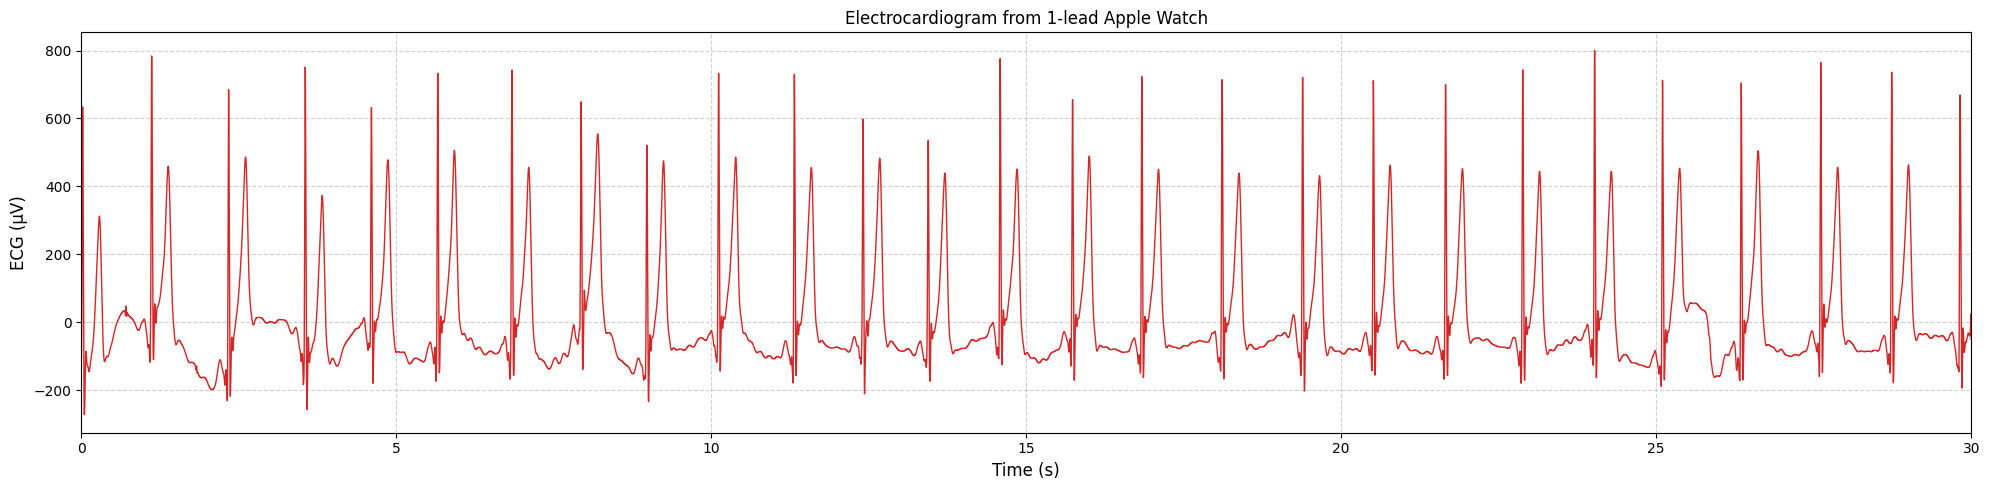

In [15]:
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---

INPUT_FILE = '/Users/mikkohapponen/Documents/Tiedostot/Koti/Terveys/electrocardiograms/ecg_2024-11-01_1.csv'

SAMPLING_FREQUENCY_HZ = 512

def transform_csv_data(input_path: str) -> list:
    """
    Reads data from an input CSV starting from line 13, transforms the numerical 
    values, and returns the result as a list of lists: [[time_sec, value], ...].

    The transformation handles:
    1. Replacing the Unicode minus sign (U+2212, '−') with a standard hyphen-minus ('-').
    2. Replacing the European-style decimal comma (',') with a standard decimal dot ('.').
    3. Calculating the time in seconds (t = n / 512) starting from 0.
    """
    print(f"Starting data transformation by reading '{input_path}'...")

    if not os.path.exists(input_path):
        print(f"Error: Input file '{input_path}' not found. Please create it first.")
        return []

    transformed_data = []
    lines_to_skip = 12
    
    try:
        with open(input_path, mode='r', newline='', encoding='utf-8') as infile:
            
            # Skip the first 12 lines (to start reading from line 13)
            print(f"Skipping the first {lines_to_skip} lines of the input file.")
            for _ in range(lines_to_skip):
                next(infile, None) 

            reader = csv.reader(infile)
            
            # 'n' is the index of the data point, starting from 0
            for n, row in enumerate(reader):
                if not row or not row[0].strip():
                    continue
                
                raw_value = row[0].strip()
                
                # 1. Replace Unicode minus sign
                # 2. Replace decimal comma with a dot
                cleaned_value_str = raw_value.replace('−', '-').replace(',', '.')
                
                try:
                    numerical_value = float(cleaned_value_str)
                    
                    # Calculate the time in seconds (t = n / Freq)
                    time_sec = n / SAMPLING_FREQUENCY_HZ
                    
                    # Store the time and value in the list
                    transformed_data.append([time_sec, numerical_value])
                    
                except ValueError:
                    print(f"Warning: Could not parse '{raw_value}' (Line {n + 1 + lines_to_skip}). Skipping.")
                    continue

    except Exception as e:
        print(f"An error occurred during file reading: {e}")
        return []
    
    print(f"Transformation complete. {len(transformed_data)} data points processed.")
    return transformed_data


def plot_transformed_data(data: list):
    """
    Accepts data directly as a variable (list of lists) and plots it.
    """
    if not data:
        print("Cannot plot: No data received.")
        return
        
    # Convert the list of lists into a Pandas DataFrame
    df = pd.DataFrame(data, columns=['Time (s)', 'Value (µV)'])

    # --- Create the Plot ---
    plt.figure(figsize=(20, 5))
    plt.xlim(0,30)
    
    # Plot the data
    plt.plot(df['Time (s)'], df['Value (µV)'], 
             linestyle='-',       # Draw lines between points
             color='#d62728',     # A deep red color
             linewidth=1)

    # Add labels and title for clarity
    plt.title('Electrocardiogram from 1-lead Apple Watch', fontsize=12)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('ECG (µV)', fontsize=12)
    
    # Add a grid for easier reading of values
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Tight layout to prevent labels from being cut off
    plt.tight_layout()
    
    print("Displaying plot. Close the plot window to continue.")
    # Display the plot
    plt.show()

if __name__ == '__main__':
    # Step 1: Transform the data and store it in a variable
    processed_data = transform_csv_data(INPUT_FILE)
    
    # Step 2: Use the variable directly for plotting
    plot_transformed_data(processed_data)

## Feature Extraction

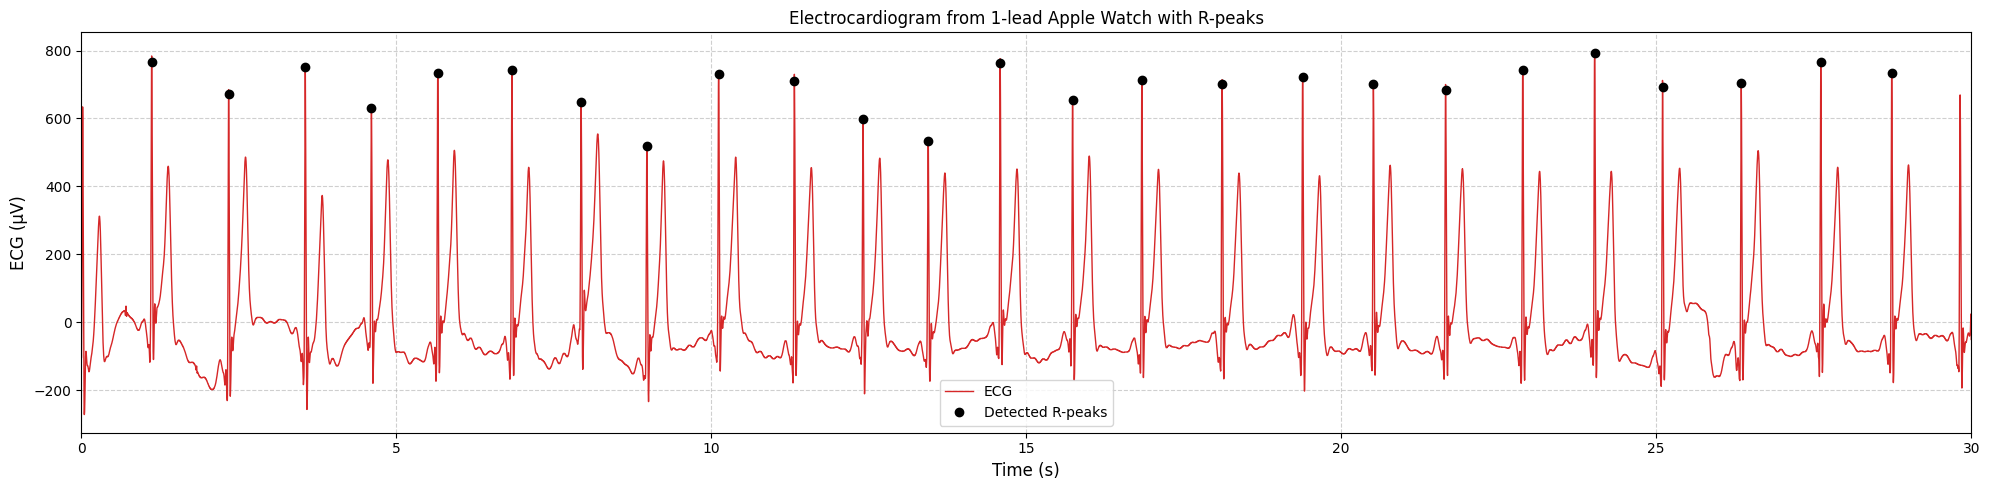

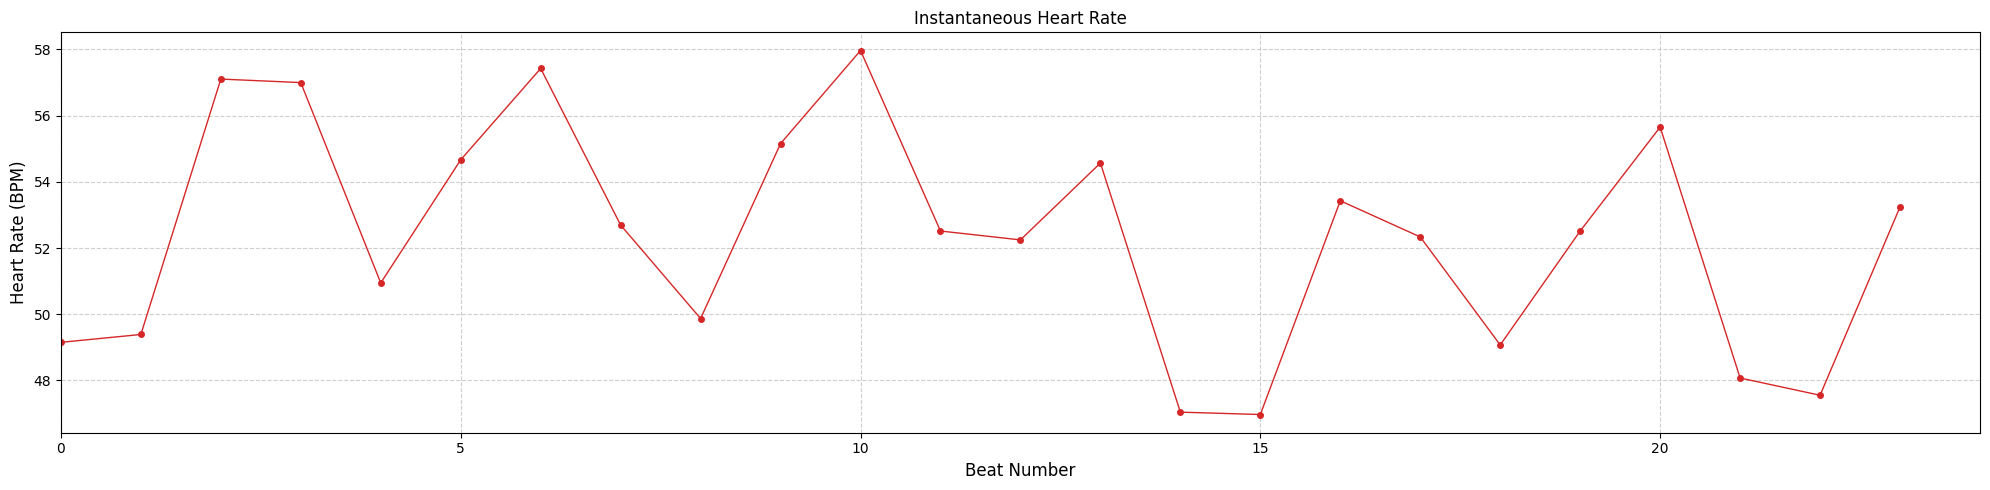

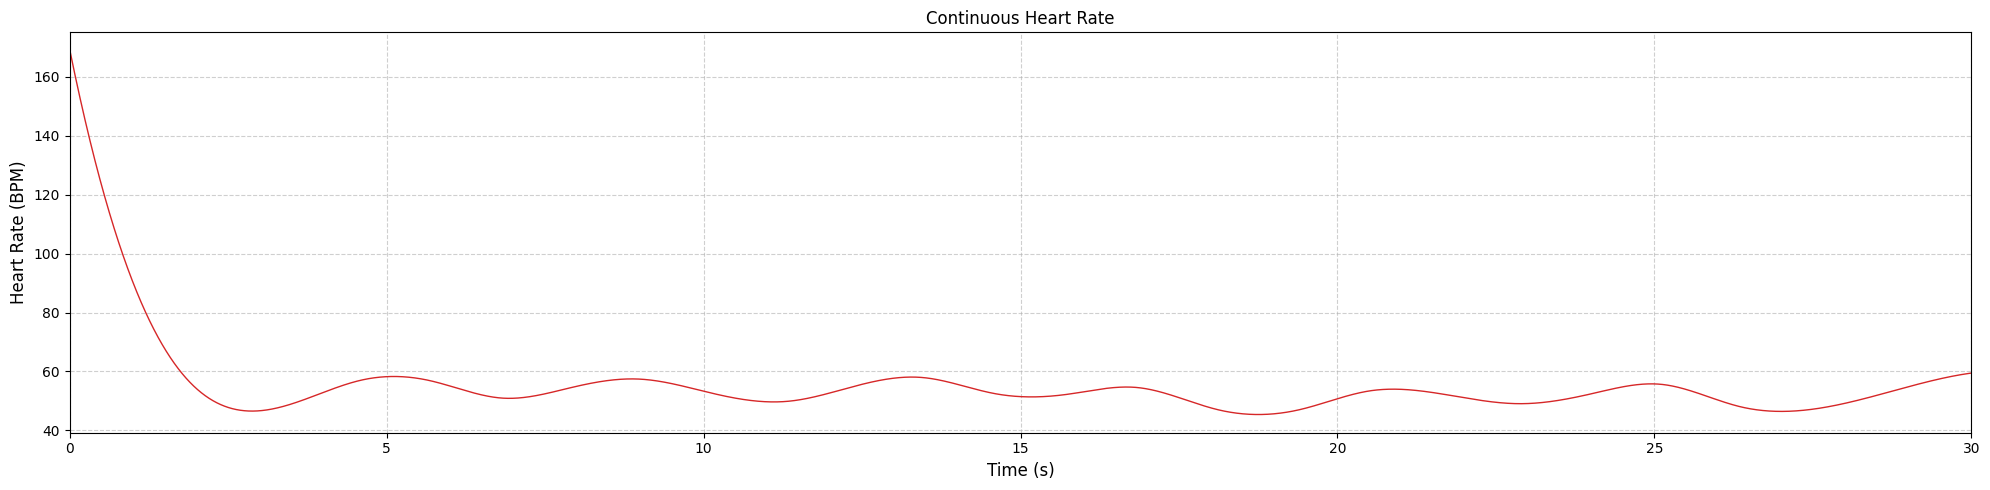

RR intervals (s): [1.22070312 1.21484375 1.05078125 1.05273438 1.17773438 1.09765625
 1.04492188 1.13867188 1.203125   1.08789062 1.03515625 1.14257812
 1.1484375  1.09960938 1.27539062 1.27734375 1.12304688 1.14648438
 1.22265625 1.14257812 1.078125   1.24804688 1.26171875 1.12695312]

Instantaneous HR (BPM): [49.152      49.38906752 57.10037175 56.99443414 50.94527363 54.66192171
 57.42056075 52.69296741 49.87012987 55.15260323 57.96226415 52.51282051
 52.24489796 54.56483126 47.04441041 46.97247706 53.42608696 52.33390119
 49.07348243 52.51282051 55.65217391 48.07511737 47.55417957 53.24090121]

Average HR (BPM): 52.35623727180675
RMSSD (s): 0.09636545021818803
SDNN (s): 0.0755974163485924
pNN50 (%): 69.56521739130434


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import biosppy
import pandas as pd

# ---------------------------------------------------------
# QRS DETECTION
# ---------------------------------------------------------

def detect_qrs(processed_data, fs=512):
    """
    Detect QRS complexes using biosppy Hamilton method.
    processed_data: list of [time, value]
    fs: sampling frequency (default: 512 Hz)
    """
    if not processed_data:
        print("No data available for QRS detection.")
        return None, None, None

    # extract time and ECG as numpy arrays
    df = pd.DataFrame(processed_data, columns=['time', 'value'])
    signal = df['value'].values
    time = df['time'].values

    # run biosppy detection
    out = biosppy.signals.ecg.ecg(signal=signal, sampling_rate=fs, show=False)
    rpeaks = out['rpeaks']

    return signal, time, rpeaks


def plot_qrs(signal, time, rpeaks):
    """
    Plot ECG with detected R-peaks using the same styling
    as plot_transformed_data().
    """
    plt.figure(figsize=(20, 5))
    plt.xlim(0,30)

    # ECG trace
    plt.plot(time, signal,
             linestyle='-',
             color='#d62728',
             linewidth=1,
             label='ECG')

    # Mark R-peaks
    plt.plot(time[rpeaks], signal[rpeaks],
             'o', color='black', markersize=6,
             label='Detected R-peaks')

    plt.title("Electrocardiogram from 1-lead Apple Watch with R-peaks", fontsize=12)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("ECG (µV)", fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# RR INTERVALS & HEART RATE
# ---------------------------------------------------------

def compute_rr_intervals(rpeaks, fs=512):
    if rpeaks is None or len(rpeaks) < 2:
        print("Not enough R-peaks to compute RR intervals.")
        return None
    return np.diff(rpeaks) / fs


def compute_heart_rate(rr_intervals_sec):
    if rr_intervals_sec is None:
        return None
    return 60.0 / rr_intervals_sec


def plot_heart_rate(hr_bpm):
    """
    Plot instantaneous heart rate using the same style.
    """
    plt.figure(figsize=(20, 5))

    plt.plot(hr_bpm,
             linestyle='-',
             color='#d62728',
             linewidth=1,
             marker='o',
             markersize=4)

    plt.title("Instantaneous Heart Rate", fontsize=12)
    plt.xlabel("Beat Number", fontsize=12)
    plt.ylabel("Heart Rate (BPM)", fontsize=12)
    plt.xlim(0,24)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# USAGE
# ---------------------------------------------------------

# Run QRS detection
signal, time, rpeaks = detect_qrs(processed_data, fs=512)

# Plot detected QRS
plot_qrs(signal, time, rpeaks)

# RR intervals and HR
rr_intervals_sec = compute_rr_intervals(rpeaks, fs=512)
hr_bpm = compute_heart_rate(rr_intervals_sec)

'''if hr_bpm is not None:
    print("RR intervals (s):", rr_intervals_sec)
    print("Instantaneous HR (BPM):", hr_bpm)
    print("Average HR (BPM):", np.mean(hr_bpm))'''

plot_heart_rate(hr_bpm)

def compute_hrv_metrics(rr_intervals_sec):
    """
    Compute common HRV time-domain metrics:
      • RMSSD    – root mean square of successive differences
      • SDNN     – standard deviation of NN intervals
      • pNN50    – percentage of differences > 50 ms
    """
    if rr_intervals_sec is None or len(rr_intervals_sec) < 2:
        print("Not enough RR intervals for HRV.")
        return None

    rr_diff = np.diff(rr_intervals_sec)

    rmssd = np.sqrt(np.mean(rr_diff**2))
    sdnn = np.std(rr_intervals_sec, ddof=1)
    pnn50 = np.sum(np.abs(rr_diff) > 0.05) / len(rr_diff) * 100.0

    return {
        "RMSSD (s)": rmssd,
        "SDNN (s)": sdnn,
        "pNN50 (%)": pnn50
    }

hrv = compute_hrv_metrics(rr_intervals_sec)

'''if hrv:
    print("\nHRV Metrics:")
    for key, value in hrv.items():
        print(f"{key}: {value}")'''

from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

def compute_continuous_hr(time, rpeaks, hr_bpm):
    """
    Generate continuous heart rate (HR(t)) using interpolation.
    
    time: full ECG time array
    rpeaks: sample indices of R-peaks
    hr_bpm: instantaneous heart rate per RR
    
    Returns: continuous_hr array aligned with 'time'
    """
    if hr_bpm is None or len(hr_bpm) == 0:
        print("No HR data for interpolation.")
        return None

    # Corresponding times for RR intervals (skip last peak)
    hr_times = time[rpeaks[1:]]

    # Create cubic interpolation function
    interp_fun = interp1d(hr_times, hr_bpm, kind='cubic', 
                          fill_value="extrapolate")

    continuous_hr = interp_fun(time)
    return continuous_hr


def plot_continuous_hr(time, continuous_hr):
    """
    Plot continuous interpolated heart rate HR(t)
    using same style as other plots.
    """
    if continuous_hr is None:
        print("No continuous HR data to plot.")
        return

    plt.figure(figsize=(20, 5))
    plt.plot(time, continuous_hr,
             linestyle='-',
             color='#d62728',
             linewidth=1)

    plt.title("Continuous Heart Rate", fontsize=12)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Heart Rate (BPM)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0,30)
    plt.tight_layout()
    plt.show()

continuous_hr = compute_continuous_hr(time, rpeaks, hr_bpm)
plot_continuous_hr(time, continuous_hr)

if hr_bpm is not None:
    print("RR intervals (s):", rr_intervals_sec)
    print("")
    print("Instantaneous HR (BPM):", hr_bpm)
    print("")
    print("Average HR (BPM):", np.mean(hr_bpm))

if hrv:
    for key, value in hrv.items():
        print(f"{key}: {value}")